In [1]:
import os
import numpy as np
import tensorflow as tf
import cv2 as cv
from tqdm import tqdm
import matplotlib.pyplot as plt
from keras.applications.vgg16 import VGG16, preprocess_input
import tensorflow.keras.layers as tfl
from sklearn import metrics

In [2]:
def loadData(dir_path):
    X = []
    y = []
    labels = dict()
    i = 0
    for path in tqdm(sorted(os.listdir(dir_path))): #traverse through directories under Train/Val/Test
        if not path.startswith('.'):
            labels[i] = path
            for file in os.listdir(dir_path+'\\'+path):
                if not file.startswith('.'):
                    img = cv.imread(dir_path+'\\'+path+'\\'+file)
                    X.append(img)
                    y.append(i)
            i=i+1
    X = np.array(X,dtype='object')
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X,y,labels


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 16.39it/s]


559 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TRAIN directory.


100%|██████████| 2/2 [00:00<00:00, 164.57it/s]


64 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\VAL directory.


100%|██████████| 2/2 [00:00<00:00, 147.26it/s]


65 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TEST directory.


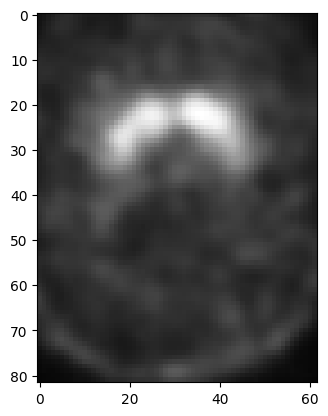

In [3]:
X_train, y_train, labels = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TRAIN')
X_val, y_val, _ = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\VAL')
X_test, y_test, _ = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TEST')
IMG_SIZE = (64,64)
plt.imshow(X_train[0])
plt.show()

In [4]:
def preprocess_imgs(set, img_size):
    set_new = []
    for img in set:
        img = cv.resize(img, dsize=img_size, interpolation=cv.INTER_CUBIC)
        set_new.append(preprocess_input(img))
    return np.array(set_new)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


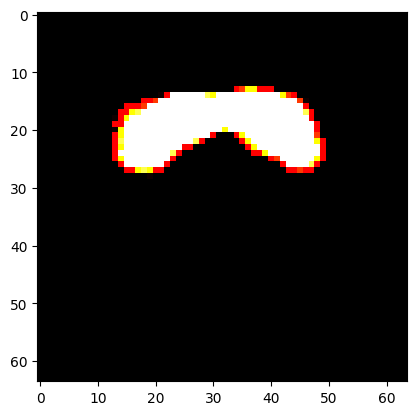

In [5]:
X_train_fin = preprocess_imgs(set=X_train,img_size=IMG_SIZE)
X_val_fin = preprocess_imgs(set=X_val,img_size=IMG_SIZE)
X_test_fin = preprocess_imgs(set=X_test,img_size=IMG_SIZE)
plt.imshow(X_train_fin[0])
plt.show()

In [6]:
model = tf.keras.Sequential([
        tfl.ZeroPadding2D(padding=(3,3), input_shape=(64,64,3)),
        tfl.Conv2D(filters = 32, strides = 1, kernel_size=(7,7)),
        tfl.BatchNormalization(axis=-1),
        tfl.ReLU(),
        tfl.Dropout(0.4),
        tfl.Conv2D(filters = 64, strides = 1, kernel_size=(5,5)),
        tfl.BatchNormalization(axis=-1),
        tfl.ReLU(),
        tfl.Dropout(0.4),
        tfl.Conv2D(filters = 64, strides = 1, kernel_size=(3,3)),
        tfl.BatchNormalization(axis=-1),
        tfl.ReLU(),
        tfl.Dropout(0.3),
        tfl.MaxPool2D(),
        tfl.Flatten(),
        tfl.Dense(units = 1, activation = 'sigmoid')
    ])

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 zero_padding2d (ZeroPadding  (None, 70, 70, 3)        0         
 2D)                                                             
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        4736      
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 64, 64, 32)        0         
                                                                 
 dropout (Dropout)           (None, 64, 64, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 60, 60, 64)        5

In [8]:
def plot_roc_curve(true_y, y_prob):

    fpr, tpr, thresholds = metrics.roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

In [9]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics='accuracy')
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3)
history = model.fit(X_train_fin,y_train,validation_data=(X_val_fin,y_val),epochs=75,batch_size=16, callbacks = [])

Epoch 1/75
35/35 [==============================] - 9s 205ms/step - loss: 3.8372 - accuracy: 0.7138 - val_loss: 32.8409 - val_accuracy: 0.3750
Epoch 2/75
24/35 [===================>..........] - ETA: 2s - loss: 0.5835 - accuracy: 0.9089

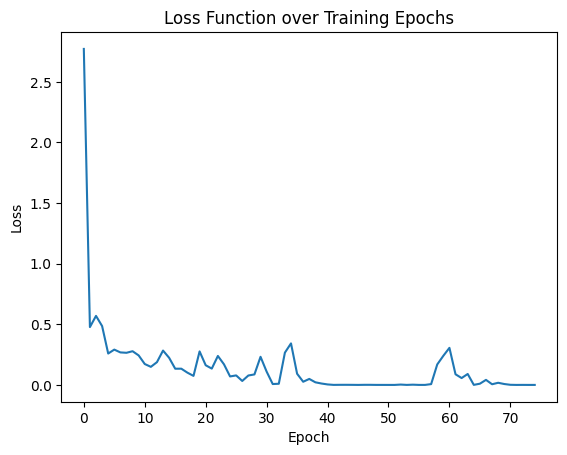

In [ ]:
loss_values = history.history['loss']

# Plot the loss function graph
plt.plot(loss_values)
plt.title('Loss Function over Training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

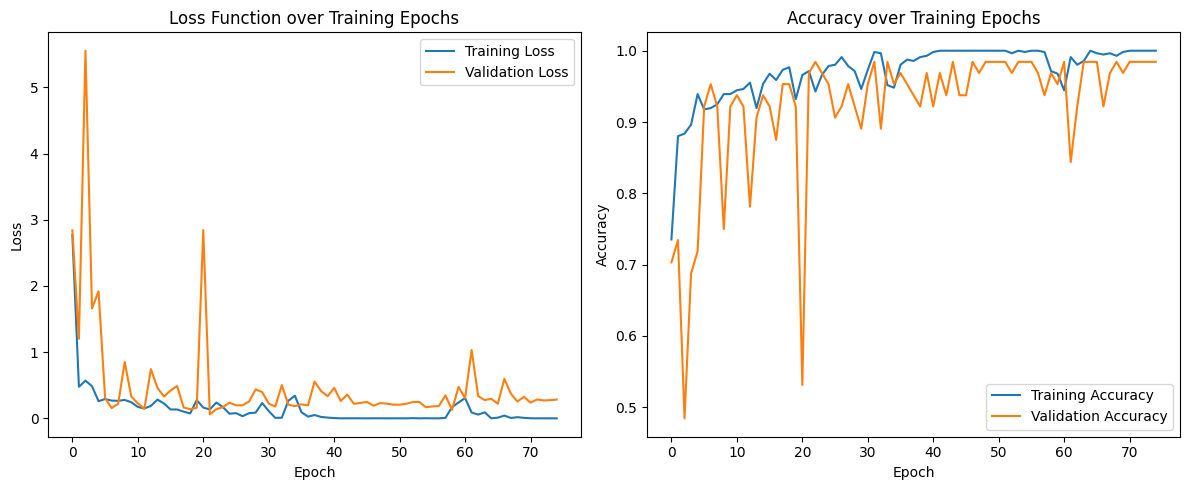

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the loss function graph
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Function over Training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.evaluate(X_val_fin,y_val)

2/2 [==============================] - 0s 69ms/step - loss: 0.2840 - accuracy: 0.9844


[0.2840006947517395, 0.984375]

In [ ]:
model.evaluate(X_test_fin,y_test)

3/3 [==============================] - 0s 46ms/step - loss: 0.0572 - accuracy: 0.9692


[0.057156700640916824, 0.9692307710647583]

In [ ]:
yhat_val = model.predict(X_val_fin)
yhat_val_fin = [1 if x>=0.5 else 0 for x in yhat_val]
yhat_test = model.predict(X_test_fin)
yhat_test_fin = [1 if x>=0.5 else 0 for x in yhat_test]


3/3 [==============================] - 0s 31ms/step


F1 measure: 0.988235294117647
ROC AUC: 0.9883720930232558


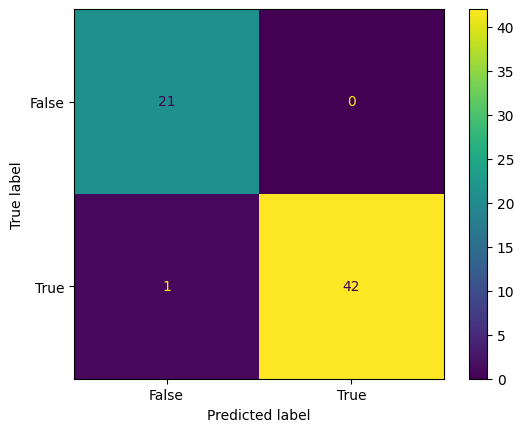

In [ ]:
confusion_matrix_val = metrics.confusion_matrix(y_val,yhat_val_fin)
cmv = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_val, display_labels = [False, True])
# plot_roc_curve(y_val,yhat_val_fin)
print(f'F1 measure: {metrics.f1_score(y_val,yhat_val_fin)}\nROC AUC: {metrics.roc_auc_score(y_val,yhat_val_fin)}')
cmv.plot()
plt.show()

F1 measure: 0.9772727272727273
ROC AUC: 0.9545454545454545


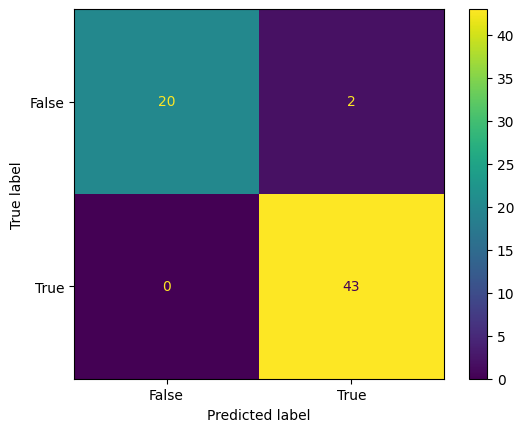

In [ ]:
confusion_matrix_test = metrics.confusion_matrix(y_test,yhat_test_fin)
cmt = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_test, display_labels = [False, True])
# plot_roc_curve(y_test,yhat_test_fin)
print(f'F1 measure: {metrics.f1_score(y_test,yhat_test_fin)}\nROC AUC: {metrics.roc_auc_score(y_test,yhat_test_fin)}')
cmt.plot()
plt.show()

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()
img = X_test_fin[1].astype(np.uint8)

c:\Users\sriha\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
explanation = explainer.explain_instance(img,model.predict,top_labels=2, hide_color = 0, num_samples = 1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 175ms/step


  1%|          | 10/1000 [00:00<00:20, 47.18it/s]

1/1 [==============================] - 0s 36ms/step


  3%|▎         | 30/1000 [00:00<00:11, 86.74it/s]

...

 97%|█████████▋| 970/1000 [00:07<00:00, 125.20it/s]

1/1 [==============================] - 0s 40ms/step


 99%|█████████▉| 990/1000 [00:07<00:00, 128.70it/s]

1/1 [==============================] - 0s 46ms/step


100%|██████████| 1000/1000 [00:07<00:00, 126.10it/s]


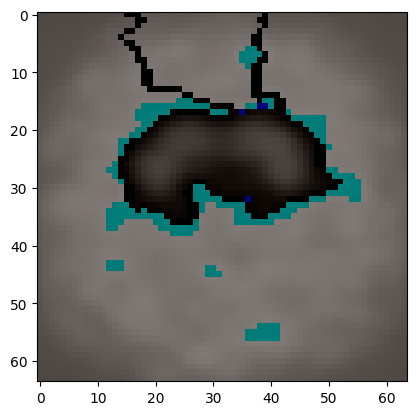

In [ ]:
temp, mask = explanation.get_image_and_mask(0,positive_only = True, num_features =5, hide_rest = False)
plt.imshow(mark_boundaries(temp/2 + 0.5,mask).astype(np.uint8))                                           

In [ ]:
model.save_weights('../SavedWeights/save_rmsprop')